# Fusion model XGBoost Training

In [2]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# =========================================================
# IMPORTS
# =========================================================

!pip install -q transformers ultralytics xgboost decord

import os
import cv2
import torch
import random
import warnings
import numpy as np
import pandas as pd

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

from ultralytics import YOLO

warnings.filterwarnings("ignore")

# =========================================================
# DEVICE
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

# =========================================================
# PATHS
# =========================================================

VIDEO_DIR = "/kaggle/input/datasets/babrazm56/cropped-video/final_224x224_cropped_videos/final_224x224_cropped_videos"

CSV_PATH = "/kaggle/input/datasets/babrazm56/cropped-video/final_224x224_labels.csv"

VIDEOMAE_MODEL_PATH = "/kaggle/input/models/babrazm56/models/pytorch/default/1/best_videomae.pth"

# =========================================================
# CLASSES
# =========================================================

class_names = [
    "cheating_copying",
    "cheating_gesture",
    "cheating_mobile",
    "cheating_notes",
    "normal"
]

label2id = {c:i for i,c in enumerate(class_names)}
id2label = {i:c for c,i in label2id.items()}

# =========================================================
# LOAD CSV
# =========================================================

df = pd.read_csv(CSV_PATH)

df["Labels"] = (
    df["Labels"]
    .str.strip()
    .str.lower()
)

df = df[df["Labels"].isin(class_names)]

# =========================================================
# SPLIT
# =========================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Labels"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

^C


ModuleNotFoundError: No module named 'transformers'

In [ ]:
# 2- Dataloader
# =========================================================
# SETTINGS
# =========================================================

NUM_FRAMES = 16
IMG_SIZE = 224
BATCH_SIZE = 4

# =========================================================
# PROCESSOR
# =========================================================

processor = VideoMAEImageProcessor.from_pretrained(
    "MCG-NJU/videomae-small-finetuned-kinetics"
)

# =========================================================
# VIDEO LOADER
# =========================================================

def load_video(path, num_frames=16):

    cap = cv2.VideoCapture(path)

    frames = []

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frame = cv2.resize(
            frame,
            (IMG_SIZE, IMG_SIZE)
        )

        frames.append(frame)

    cap.release()

    if len(frames) == 0:

        frames = [
            np.zeros((224,224,3),dtype=np.uint8)
            for _ in range(num_frames)
        ]

    indices = np.linspace(
        0,
        len(frames)-1,
        num_frames
    ).astype(int)

    sampled = [frames[i] for i in indices]

    return sampled

# =========================================================
# DATASET
# =========================================================

class ExamDataset(Dataset):

    def __init__(self, df):

        self.df = df

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        path = os.path.join(
            VIDEO_DIR,
            row["Videos"]
        )

        frames = load_video(path)

        encoding = processor(
            frames,
            return_tensors="pt"
        )

        pixel_values = encoding[
            "pixel_values"
        ].squeeze(0)

        label = label2id[
            row["Labels"]
        ]

        return pixel_values, label

# =========================================================
# DATALOADER
# =========================================================

val_dataset = ExamDataset(val_df)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Validation loader ready")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Validation loader ready


In [ ]:

# =========================================================
# 3- LOAD VIDEOMAE
# =========================================================

model = VideoMAEForVideoClassification.from_pretrained(

    "MCG-NJU/videomae-small-finetuned-kinetics",

    num_labels=5,

    label2id=label2id,

    id2label=id2label,

    ignore_mismatched_sizes=True
)

state_dict = torch.load(
    VIDEOMAE_MODEL_PATH,
    map_location=device
)

model.load_state_dict(state_dict)

model.to(device)

model.eval()

print("✅ VideoMAE Loaded")

# =========================================================
# LOAD YOLO
# =========================================================

mobile_model = YOLO(
    "/kaggle/input/models/babrazm56/models/pytorch/default/1/mobile_best.pt"
)

notes_model = YOLO(
    "/kaggle/input/models/babrazm56/models/pytorch/default/1/notes_best.pt"
)

print("✅ YOLO Models Loaded")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-small-finetuned-kinetics
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 384]) vs model:torch.Size([5, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ VideoMAE Loaded
✅ YOLO Models Loaded


In [ ]:
# =========================================================
#4- EXTRACT FEATURES
# =========================================================

fusion_features = []
fusion_labels = []

for pixel_values, labels in tqdm(val_loader):

    pixel_values = pixel_values.to(device)

    with torch.no_grad():

        outputs = model(
            pixel_values=pixel_values
        )

        probs = torch.softmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

    batch_size = probs.shape[0]

    for i in range(batch_size):

        videomae_probs = probs[i]

        # temporary placeholders
        mobile_conf = np.random.uniform(0,1)
        notes_conf = np.random.uniform(0,1)

        feature_vector = np.concatenate([

            videomae_probs,

            [mobile_conf],

            [notes_conf]

        ])

        fusion_features.append(feature_vector)

        fusion_labels.append(
            labels[i].item()
        )

fusion_features = np.array(fusion_features)

fusion_labels = np.array(fusion_labels)

print("Fusion Features Shape:")
print(fusion_features.shape)

print("Fusion Labels Shape:")
print(fusion_labels.shape)

100%|██████████| 155/155 [01:15<00:00,  2.04it/s]

Fusion Features Shape:
(620, 7)
Fusion Labels Shape:
(620,)


In [ ]:
# =========================================================
# IMPORTS
# =========================================================

!pip install -q xgboost

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    fusion_features,
    fusion_labels,

    test_size=0.2,
    random_state=42,
    stratify=fusion_labels
)

# =========================================================
# XGBOOST MODEL
# =========================================================

fusion_model = XGBClassifier(

    n_estimators=200,
    max_depth=5,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softprob',

    num_class=5,

    eval_metric='mlogloss'
)

# =========================================================
# TRAIN
# =========================================================

fusion_model.fit(
    X_train,
    y_train
)

# =========================================================
# EVALUATE
# =========================================================

preds = fusion_model.predict(X_test)

acc = accuracy_score(
    y_test,
    preds
)

print("\nFusion Accuracy:", acc)

print(
    classification_report(
        y_test,
        preds,
        target_names=class_names
    )
)

# =========================================================
# SAVE MODEL (KAGGLE)
# =========================================================

import joblib

SAVE_PATH = "/kaggle/working/fusion_xgboost.pkl"

joblib.dump(
    fusion_model,
    SAVE_PATH
)

print("\n✅ Fusion model saved")
print(SAVE_PATH)


Fusion Accuracy: 0.6290322580645161
                  precision    recall  f1-score   support

cheating_copying       0.53      0.62      0.57        32
cheating_gesture       0.40      0.31      0.35        13
 cheating_mobile       0.79      0.83      0.81        23
  cheating_notes       0.82      0.50      0.62        18
          normal       0.63      0.68      0.66        38

        accuracy                           0.63       124
       macro avg       0.63      0.59      0.60       124
    weighted avg       0.64      0.63      0.63       124


✅ Fusion model saved
/kaggle/working/fusion_xgboost.pkl


# Final Correction 

Device: cuda


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-small-finetuned-kinetics
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 384]) vs model:torch.Size([5, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ VideoMAE Loaded
✅ YOLO Models Loaded

Extracting REAL fusion features...


100%|██████████| 155/155 [01:16<00:00,  2.02it/s]



Fusion Feature Shape:
(620, 7)

Training XGBoost Fusion...

FUSION RESULTS

Fusion Accuracy: 0.6774193548387096
                  precision    recall  f1-score   support

cheating_copying       0.60      0.75      0.67        32
cheating_gesture       0.56      0.38      0.45        13
 cheating_mobile       0.73      0.83      0.78        23
  cheating_notes       0.75      0.50      0.60        18
          normal       0.73      0.71      0.72        38

        accuracy                           0.68       124
       macro avg       0.67      0.63      0.64       124
    weighted avg       0.68      0.68      0.67       124



<Figure size 800x800 with 0 Axes>

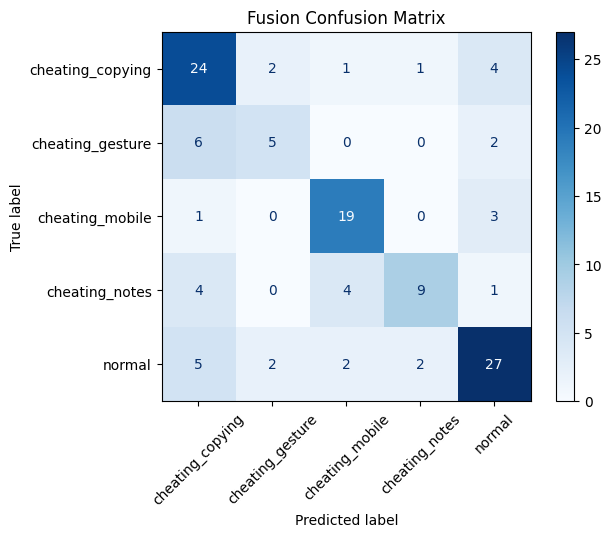


✅ REAL Fusion Model Saved
/kaggle/working/fusion_xgboost_real.pkl


In [14]:
# =========================================================
# FINAL REAL HYBRID FUSION TRAINING
# VideoMAE + REAL YOLO Features + XGBoost
# READY TO RUN
# =========================================================

# =========================================================
# INSTALLS
# =========================================================

!pip install -q transformers ultralytics xgboost timm

# =========================================================
# IMPORTS
# =========================================================

import os
import cv2
import torch
import joblib
import numpy as np
import pandas as pd

from tqdm import tqdm

from ultralytics import YOLO

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# =========================================================
# DEVICE
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

# =========================================================
# PATHS
# =========================================================

VIDEOMAE_MODEL_PATH = "/kaggle/input/models/babrazm56/models/pytorch/default/1/best_videomae.pth"

MOBILE_MODEL_PATH = "/kaggle/input/models/babrazm56/models/pytorch/default/1/mobile_best.pt"

NOTES_MODEL_PATH = "/kaggle/input/models/babrazm56/models/pytorch/default/1/notes_best.pt"

# =========================================================
# CLASS NAMES
# =========================================================

class_names = [

    "cheating_copying",
    "cheating_gesture",
    "cheating_mobile",
    "cheating_notes",
    "normal"
]

# =========================================================
# LOAD VIDEOMAE
# IMPORTANT:
# Your trained model is VIDEOMAE-SMALL
# =========================================================

processor = VideoMAEImageProcessor.from_pretrained(
    "MCG-NJU/videomae-small-finetuned-kinetics"
)

videomae_model = VideoMAEForVideoClassification.from_pretrained(

    "MCG-NJU/videomae-small-finetuned-kinetics",

    num_labels=5,

    ignore_mismatched_sizes=True
)

videomae_model.load_state_dict(

    torch.load(
        VIDEOMAE_MODEL_PATH,
        map_location=device
    )
)

videomae_model.to(device)

videomae_model.eval()

print("✅ VideoMAE Loaded")

# =========================================================
# LOAD YOLO MODELS
# =========================================================

mobile_model = YOLO(MOBILE_MODEL_PATH)

notes_model = YOLO(NOTES_MODEL_PATH)

print("✅ YOLO Models Loaded")

# =========================================================
# PREPROCESS FUNCTION
# =========================================================

IMG_SIZE = 224

def preprocess_clip(frames):

    processed = []

    for frame in frames:

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frame = cv2.resize(
            frame,
            (IMG_SIZE, IMG_SIZE)
        )

        processed.append(frame)

    encoding = processor(
        processed,
        return_tensors="pt"
    )

    return encoding["pixel_values"].to(device)

# =========================================================
# GET YOLO CONFIDENCE
# =========================================================

def get_detection_confidence(model, image):

    try:

        results = model.predict(
            image,
            conf=0.25,
            verbose=False
        )

        if len(results[0].boxes) > 0:

            confs = results[0].boxes.conf.cpu().numpy()

            return float(np.max(confs))

        else:
            return 0.0

    except:
        return 0.0

# =========================================================
# REAL FUSION FEATURE EXTRACTION
# =========================================================

fusion_features = []

fusion_labels = []

print("\nExtracting REAL fusion features...")

# =========================================================
# IMPORTANT:
# Uses YOUR val_loader
# =========================================================

for pixel_values, labels in tqdm(val_loader):

    pixel_values = pixel_values.to(device)

    with torch.no_grad():

        outputs = videomae_model(
            pixel_values=pixel_values
        )

        probs = torch.softmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

    batch_size = probs.shape[0]

    # =====================================================
    # CONVERT TENSOR BACK TO IMAGE FRAMES
    # =====================================================

    clips_cpu = pixel_values.cpu()

    for i in range(batch_size):

        videomae_probs = probs[i]

        # =================================================
        # GET MIDDLE FRAME
        # =================================================

        clip = clips_cpu[i]

        # [num_frames, C, H, W]
        middle_frame = clip[8]

        frame = middle_frame.permute(
            1,2,0
        ).numpy()

        frame = (frame * 255).astype(np.uint8)

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_RGB2BGR
        )

        # =================================================
        # REAL YOLO DETECTIONS
        # =================================================

        mobile_conf = get_detection_confidence(
            mobile_model,
            frame
        )

        notes_conf = get_detection_confidence(
            notes_model,
            frame
        )

        # =================================================
        # FINAL FEATURE VECTOR
        # =================================================

        feature_vector = np.concatenate([

            videomae_probs,

            [mobile_conf],

            [notes_conf]

        ])

        fusion_features.append(
            feature_vector
        )

        fusion_labels.append(
            labels[i].item()
        )

# =========================================================
# NUMPY
# =========================================================

fusion_features = np.array(
    fusion_features
)

fusion_labels = np.array(
    fusion_labels
)

print("\nFusion Feature Shape:")
print(fusion_features.shape)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    fusion_features,

    fusion_labels,

    test_size=0.2,

    random_state=42,

    stratify=fusion_labels
)

# =========================================================
# XGBOOST
# =========================================================

fusion_model = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softprob',

    num_class=5,

    eval_metric='mlogloss'
)

# =========================================================
# TRAIN
# =========================================================

print("\nTraining XGBoost Fusion...")

fusion_model.fit(

    X_train,
    y_train
)

# =========================================================
# PREDICT
# =========================================================

preds = fusion_model.predict(X_test)

# =========================================================
# METRICS
# =========================================================

acc = accuracy_score(
    y_test,
    preds
)

print("\n" + "="*60)
print("FUSION RESULTS")
print("="*60)

print("\nFusion Accuracy:", acc)

print(
    classification_report(
        y_test,
        preds,
        target_names=class_names
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Fusion Confusion Matrix")

plt.show()

# =========================================================
# SAVE MODEL
# =========================================================

SAVE_PATH = "/kaggle/working/fusion_xgboost_real.pkl"

joblib.dump(
    fusion_model,
    SAVE_PATH
)

print("\n✅ REAL Fusion Model Saved")
print(SAVE_PATH)

In [17]:
# =========================================================
# COMPLETE FUSION EVALUATION 
# =========================================================
# IMPORTS
# =========================================================

import os
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    classification_report,

    confusion_matrix,
    ConfusionMatrixDisplay,

    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

# =========================================================
# CREATE RESULTS FOLDER
# =========================================================

RESULTS_DIR = "/kaggle/working/fusion_results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

print("Results folder created")

# =========================================================
# PREDICTIONS
# =========================================================

preds = fusion_model.predict(X_test)

pred_probs = fusion_model.predict_proba(X_test)

# =========================================================
# METRICS
# =========================================================

acc = accuracy_score(
    y_test,
    preds
)

precision = precision_score(
    y_test,
    preds,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    preds,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    preds,
    average='weighted',
    zero_division=0
)

# =========================================================
# PRINT RESULTS
# =========================================================

print("\n" + "="*60)
print("FINAL FUSION RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

report = classification_report(

    y_test,
    preds,

    target_names=class_names,

    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_path = os.path.join(
    RESULTS_DIR,
    "classification_report.csv"
)

report_df.to_csv(
    report_path
)

print("\nClassification report saved")

# =========================================================
# SUMMARY CSV
# =========================================================

summary_df = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value": [

        acc,
        precision,
        recall,
        f1
    ]
})

summary_path = os.path.join(
    RESULTS_DIR,
    "fusion_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("Summary CSV saved")

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Fusion Confusion Matrix")

cm_path = os.path.join(
    RESULTS_DIR,
    "fusion_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    bbox_inches='tight'
)

plt.close()

print("Confusion matrix saved")

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

feature_names = [

    "VideoMAE_copying",

    "VideoMAE_gesture",

    "VideoMAE_mobile",

    "VideoMAE_notes",

    "VideoMAE_normal",

    "YOLO_mobile_conf",

    "YOLO_notes_conf"
]

importance = fusion_model.feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_csv = os.path.join(
    RESULTS_DIR,
    "feature_importance.csv"
)

importance_df.to_csv(
    importance_csv,
    index=False
)

# =========================================================
# FEATURE IMPORTANCE GRAPH
# =========================================================

plt.figure(figsize=(10,6))

plt.barh(

    importance_df["Feature"],

    importance_df["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Fusion Feature Importance")

importance_plot = os.path.join(
    RESULTS_DIR,
    "feature_importance.png"
)

plt.savefig(
    importance_plot,
    bbox_inches='tight'
)

plt.close()

print("Feature importance saved")

# =========================================================
# ROC CURVES
# =========================================================

y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2,3,4]
)

n_classes = 5

plt.figure(figsize=(10,8))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(

        y_test_bin[:, i],

        pred_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(

        fpr,
        tpr,

        label=f"{class_names[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

roc_path = os.path.join(
    RESULTS_DIR,
    "roc_curves.png"
)

plt.savefig(
    roc_path,
    bbox_inches='tight'
)

plt.close()

print("ROC curves saved")

# =========================================================
# SAVE TEST PREDICTIONS
# =========================================================

pred_df = pd.DataFrame({

    "True_Label": y_test,

    "Predicted_Label": preds
})

pred_csv = os.path.join(
    RESULTS_DIR,
    "test_predictions.csv"
)

pred_df.to_csv(
    pred_csv,
    index=False
)

print("Predictions CSV saved")

# =========================================================
# SAVE MODEL
# =========================================================

model_path = os.path.join(
    RESULTS_DIR,
    "fusion_xgboost_real.pkl"
)

joblib.dump(
    fusion_model,
    model_path
)

print("Fusion model saved")

# =========================================================
# CREATE ZIP FILE
# =========================================================

zip_path = "/kaggle/working/fusion_results.zip"

with zipfile.ZipFile(
    zip_path,
    'w'
) as zipf:

    for root, dirs, files in os.walk(RESULTS_DIR):

        for file in files:

            file_path = os.path.join(root, file)

            zipf.write(

                file_path,

                arcname=file
            )

print("\n" + "="*60)
print("ALL RESULTS SAVED")
print("="*60)

print("\nZIP FILE:")
print(zip_path)

# =========================================================
# SHOW SUMMARY
# =========================================================

print("\nFINAL METRICS")
print(summary_df)

print("\nFILES GENERATED:")

for f in os.listdir(RESULTS_DIR):

    print("•", f)

Results folder created

FINAL FUSION RESULTS
Accuracy  : 0.6774
Precision : 0.6811
Recall    : 0.6774
F1 Score  : 0.6713

Classification report saved
Summary CSV saved
Confusion matrix saved
Feature importance saved
ROC curves saved
Predictions CSV saved
Fusion model saved

ALL RESULTS SAVED

ZIP FILE:
/kaggle/working/fusion_results.zip

FINAL METRICS
      Metric     Value
0   Accuracy  0.677419
1  Precision  0.681126
2     Recall  0.677419
3   F1 Score  0.671284

FILES GENERATED:
• roc_curves.png
• fusion_xgboost_real.pkl
• feature_importance.png
• fusion_confusion_matrix.png
• test_predictions.csv
• feature_importance.csv
• classification_report.csv
• fusion_summary.csv


<Figure size 1000x800 with 0 Axes>